In [ ]:
# Autoencoders

Variants of Autoencoders:

Undercomplete Autoencoder (vanilla)
    Bottleneck < input dimension → forces learning compact representation
Denoising Autoencoder
    Input is corrupted, but output must match the original
Sparse Autoencoder
    Add regularization (e.g., L1 penalty) to enforce sparsity in latent representation
Variational Autoencoder (VAE)
    Probabilistic autoencoder, used in generative modeling

In [ ]:
 Motivation: Why Autoencoders?

    Problem Context: Dimensionality reduction, data compression, denoising, anomaly detection.

    Compare With PCA: Both reduce dimensions, but autoencoders are nonlinear.

In [ ]:
 Basics of Autoencoders

Core Concept:
    Autoencoder is a type of neural network that learns to encode input data into a smaller representation and then decode it back to the original.
Architecture:
    Input Layer → Encoder → Latent Space (Bottleneck) → Decoder → Output Layer   
Trained to minimize reconstruction error (e.g., MSE between input and output)
 Math:

Let x∈Rn be input
    Encoder: h=f(x)=σ(Wex+be)
    Decoder: x^=g(h)=σ(Wdh+bd)
    Loss: L(x,x^)=∥x−x^∥2

# An autoencoder is a neural network that compresses the input data into a lower-dimensional representation using nonlinear transformations, and then tries to reconstruct the original data from that compressed version

In [ ]:
Embedding = Latent Representation = Bottleneck Code

The output of the encoder (before the decoder starts) is often called:
        Latent Vector
        Latent Code
        Latent Space
        Embedding
        Compressed Representation

It's a lower-dimensional, dense, learned representation of the original input.
It captures the most important features or structure in the input data.
The decoder tries to reconstruct the original from only this vector.

In [ ]:
The latent space is what the model learns — a compressed, abstract version that captures the core features.

In [ ]:
| Method          | Type         | Linear/Nonlinear | Supervised? | What It Learns                        | Handles Complex Data?       |
| --------------- | ------------ | ---------------- | ----------- | ------------------------------------- | --------------------------- |
| **PCA**         | Unsupervised | Linear           | No        | Directions of max variance            | No (only linear)          |
| **LDA**         | Supervised   | Linear           | Yes       | Directions that best separate classes | No (only linear)          |
| **Autoencoder** | Unsupervised | **Nonlinear**    | No        | Learns nonlinear latent structure     | Yes (images, audio, etc.) |


The encoder network in an autoencoder learns to create embeddings of the input — compressed vectors that represent the essence of the data. These embeddings form is what we call the latent space


In [ ]:
To do this well, encoder will find combinations of features that preserve the "essence" of the input.

Example: For digits, it might capture stroke direction, loop shapes, thickness, etc.
It is learning structure — like:

    Symmetry
    Shape
    Texture
    Continuity
    Closeness in feature space


In [ ]:
So, 
The encoder is a neural network — just like any other — with:

    An input layer
    One or more hidden layers
    An output layer (which gives the latent vector / embedding)

The decoder is another neural network that has input, hidden and output layer

Ideally, it is all fully connected to each other ! 

# So Autoencoder is Just two back-to-back neural networks

so how does it calculates error or miminize errors, in this case. Because, so far we had learned that error back propagates back to the initial input layer on the same network. But here the back porpagation comes from the output of decoder and then goes to the input of encoder.

Thus, 
The encoder does not have a separate loss function or feedback:
it learns via the same error signal that guides the decoder.
Both networks are tightly coupled during training to minimize reconstruction error.

In [ ]:
so, it is joint error propagation:

Encoder takes input x and transforms it into a latent vector h=f(x).

Decoder takes this h and reconstructs an output x^=g(h).

We compute the reconstruction loss:
L=∥x−x^∥2(MSE)
or
L=−∑[xilog⁡x^i+(1−xi)log⁡(1−x^i)](BCE)

This loss backpropagates through the decoder and then through the encoder, updating both sets of weights simultaneously.

Over many iterations, encoder learns a representation that makes reconstruction easier, 
while decoder learns how to reconstruct from that representation

In [ ]:
# Example

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [4]:
# sample dataset

transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)


100%|██████████████████████████████████████| 9.91M/9.91M [00:04<00:00, 2.29MB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 87.8kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:04<00:00, 358kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.53MB/s]


In [5]:
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [6]:
num_epochs = 5

for epoch in range(num_epochs):
    for images, _ in train_loader:
        output = model(images)
        loss = criterion(output, images.view(-1, 28*28))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/5], Loss: 0.0316
Epoch [2/5], Loss: 0.0202
Epoch [3/5], Loss: 0.0188
Epoch [4/5], Loss: 0.0147
Epoch [5/5], Loss: 0.0153


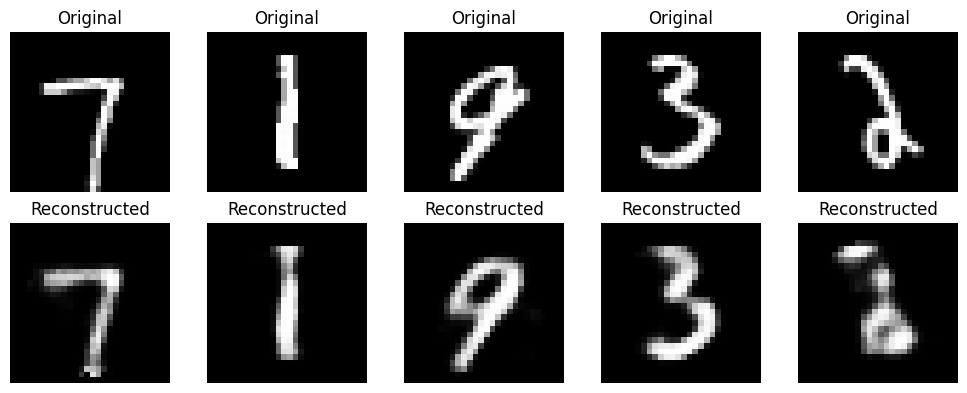

In [7]:

test_img = next(iter(train_loader))[0][:5]
with torch.no_grad():
    reconstructed = model(test_img)

# Show original and reconstructed images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(test_img[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(reconstructed[i].view(28, 28), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[0, i].axis('off')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()



# Denoising AE (just to make sure it learns the underlying patterns)

In [ ]:
A Denoising Autoencoder is simply a neural network trained to reconstruct the original clean input from a noisy version of it.

It’s a training objective, not an architectural constraint.

We deliberately corrupt the input (e.g., add Gaussian noise to images). The model is still asked to reconstruct the original clean input.

Our Goal: 
The autoencoder learns features that are robust to noise — it doesn't memorize noisy inputs, it generalizes underlying patterns.

In [ ]:
| Architecture Type           | Can be used for Denoising? | Example Use Case                                                               |
| --------------------------- | -------------------------- | ------------------------------------------------------------------------------ |
| **Fully Connected (Dense)** | Yes                      | When inputs are flat vectors (e.g., tabular data, flattened images like MNIST) |
| **Convolutional**           | Yes                      | When preserving spatial structure matters (e.g., images like CIFAR, photos)    |
| **Recurrent**               | Yes                      | For sequential/noisy time-series or text data                                  |


Epoch [1/10], Loss: 0.2934
Epoch [2/10], Loss: 0.2399
Epoch [3/10], Loss: 0.2106
Epoch [4/10], Loss: 0.1824
Epoch [5/10], Loss: 0.1696
Epoch [6/10], Loss: 0.1627
Epoch [7/10], Loss: 0.1589
Epoch [8/10], Loss: 0.1561
Epoch [9/10], Loss: 0.1534
Epoch [10/10], Loss: 0.1508


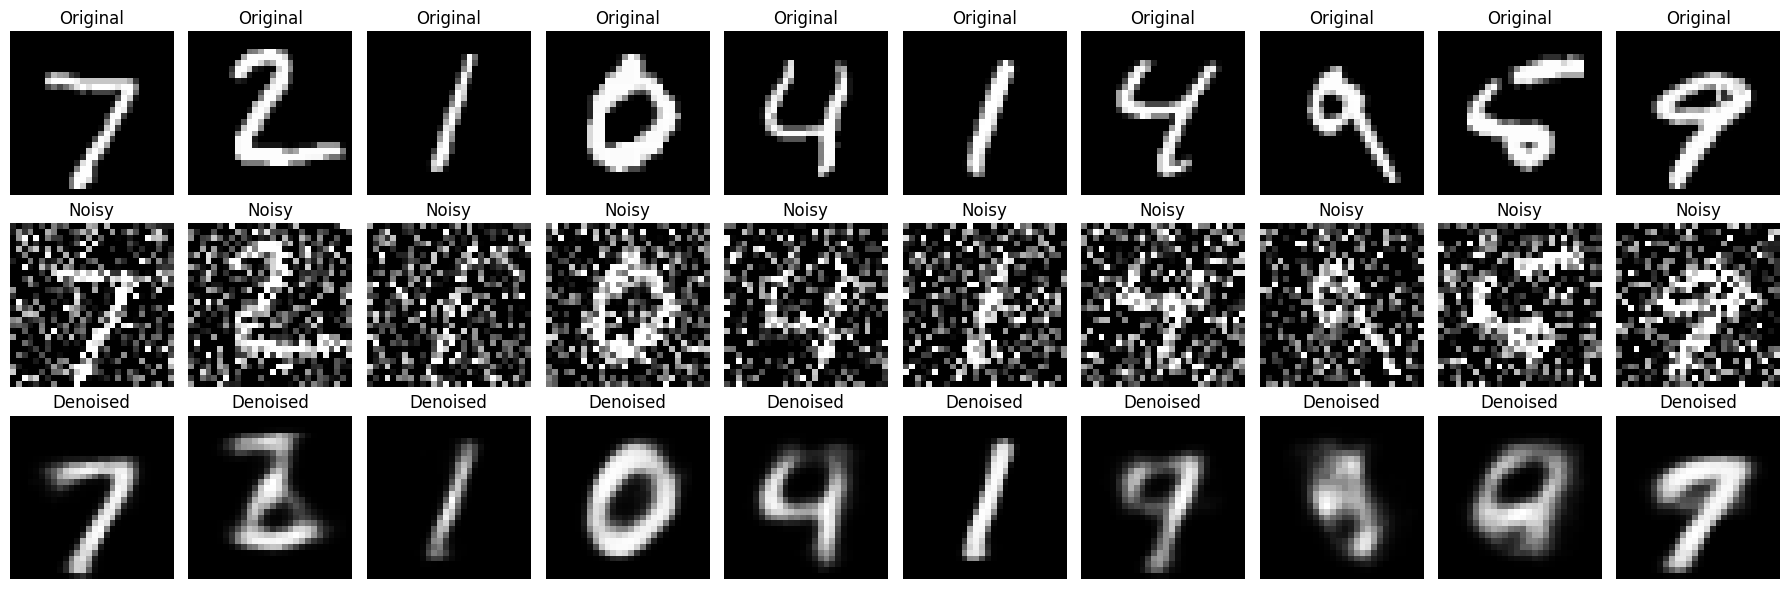

In [10]:
# Learn to reconstruct the original (clean) data even when the input is corrupted with noise.

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and normalize MNIST
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Flatten the images (28x28 -> 784)
x_train = train_dataset.data.view(-1, 784).float() / 255.
x_test = test_dataset.data.view(-1, 784).float() / 255.

# Add Gaussian noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * torch.randn_like(x_train)
x_test_noisy = x_test + noise_factor * torch.randn_like(x_test)
x_train_noisy = torch.clamp(x_train_noisy, 0., 1.)
x_test_noisy = torch.clamp(x_test_noisy, 0., 1.)

# Wrap into DataLoaders
batch_size = 256
train_loader = DataLoader(TensorDataset(x_train_noisy, x_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test_noisy, x_test), batch_size=batch_size, shuffle=False)

# Define Denoising Autoencoder Model
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 32),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instantiate model, loss, optimizer
model = DenoisingAutoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

# Predict on test
model.eval()
with torch.no_grad():
    noisy_imgs, clean_imgs = next(iter(test_loader))
    noisy_imgs = noisy_imgs.to(device)
    outputs = model(noisy_imgs).cpu().numpy()
    noisy_imgs = noisy_imgs.cpu().numpy()
    clean_imgs = clean_imgs.numpy()

# Plot
n = 10
plt.figure(figsize=(18, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(clean_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(outputs[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
# Visualizing AE

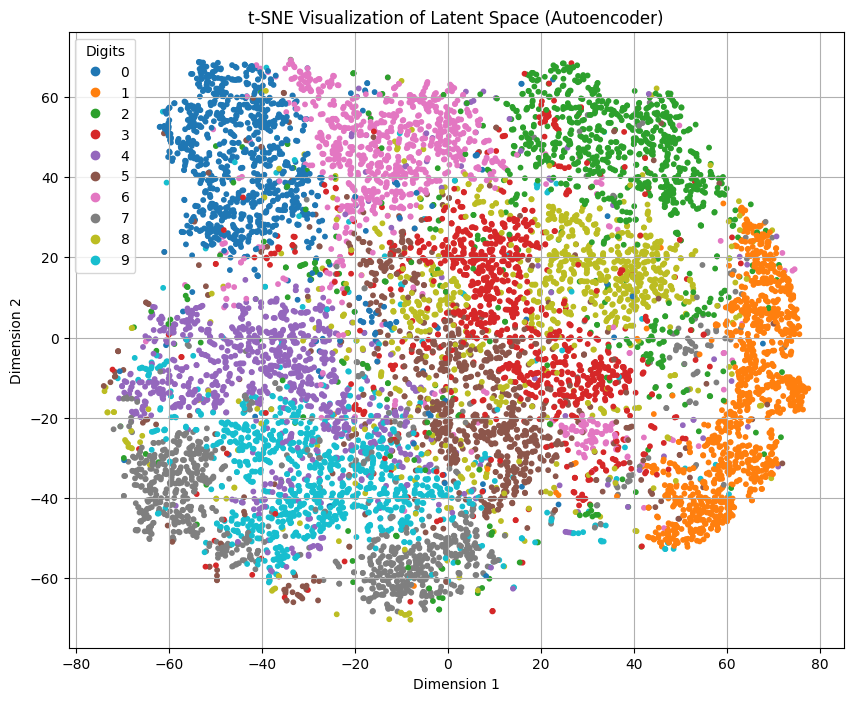

In [11]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST
transform = transforms.ToTensor()
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=512, shuffle=False)

# Define Encoder-Decoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32)  # Latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
        
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

autoencoder = Autoencoder()
torch.save(autoencoder.state_dict(), 'autoencoder.pth')
# Load pretrained model (or train it yourself)
# Assume you already trained and saved it: torch.save(autoencoder.state_dict(), 'autoencoder.pth')
# If not trained, do training first before continuing
autoencoder.load_state_dict(torch.load('autoencoder.pth'))
autoencoder.eval()

# Extract latent space from encoder
all_latents = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        latent_vectors = autoencoder.encoder(imgs)
        all_latents.append(latent_vectors)
        all_labels.append(labels)

X_latent = torch.cat(all_latents).numpy()
y_true = torch.cat(all_labels).numpy()

# Use t-SNE to reduce 32D to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_latent)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("t-SNE Visualization of Latent Space (Autoencoder)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()


Training Denoising Autoencoder...
Epoch 1, Loss: 0.0345
Epoch 2, Loss: 0.0278
Epoch 3, Loss: 0.0222
Epoch 4, Loss: 0.0208
Epoch 5, Loss: 0.0184
Running t-SNE...


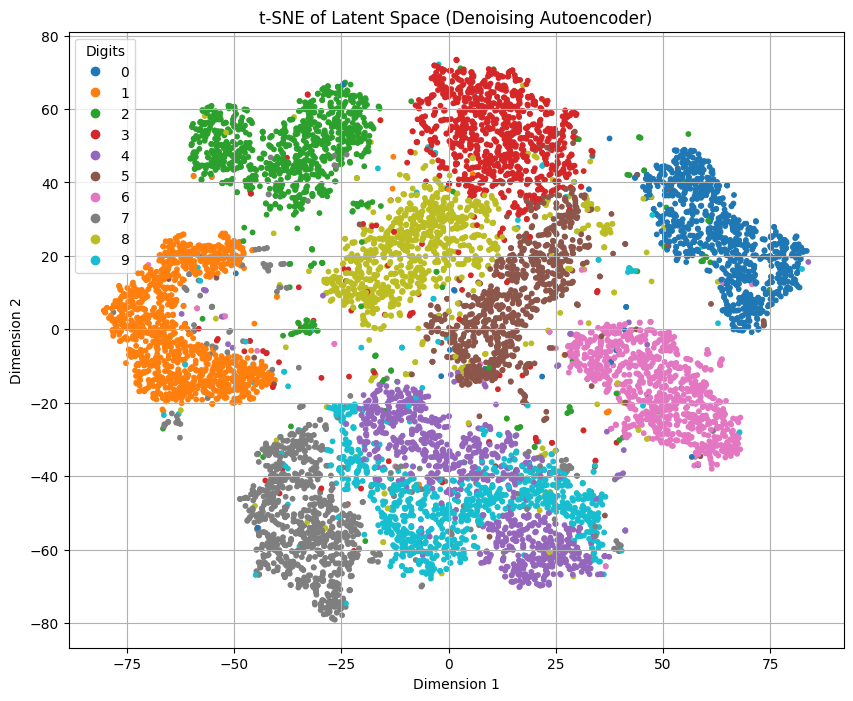

In [12]:
# Denoising AE

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST Dataset with Tensor conversion
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=False)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=512, shuffle=False)

# Denoising Autoencoder Definition
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

dae = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(dae.parameters(), lr=1e-3)

# Training with Noise Injection
def add_noise(x, noise_factor=0.4):
    x_noisy = x + noise_factor * torch.randn_like(x)
    return torch.clip(x_noisy, 0., 1.)

print("Training Denoising Autoencoder...")
for epoch in range(5):  # You can increase to 20 for better results
    dae.train()
    for batch in train_loader:
        imgs, _ = batch
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs)

        outputs = dae(noisy_imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Latent Vector Extraction from Test Set
dae.eval()
latents = []
labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs)
        z = dae.encoder(noisy_imgs)
        latents.append(z.cpu())
        labels.append(lbls)

X_latent = torch.cat(latents).numpy()
y_true = torch.cat(labels).numpy()

# t-SNE and Visualization
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_latent)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="tab10", s=10)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("t-SNE of Latent Space (Denoising Autoencoder)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()


In [ ]:
# noisy input, reconstructed output, and the original clean image

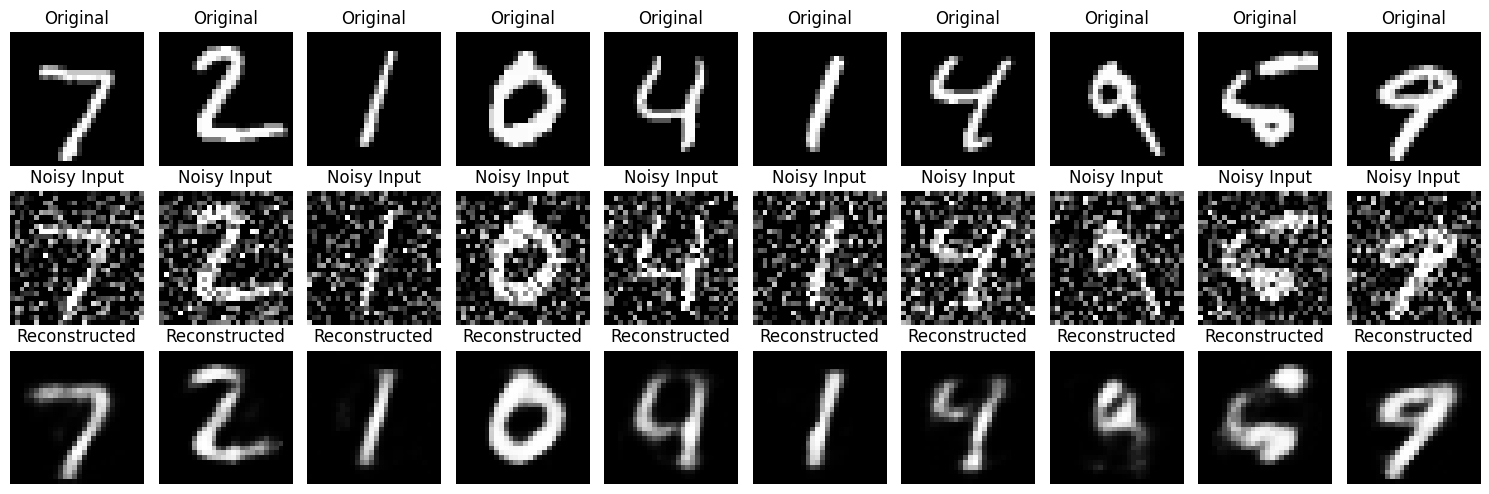

In [14]:
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Switch to eval mode
dae.eval()

# Pick a few test images and move to device
test_imgs = next(iter(test_loader))[0][:10].to(device)
noisy_test_imgs = add_noise(test_imgs).to(device)

# Pass through autoencoder
with torch.no_grad():
    reconstructed = dae(noisy_test_imgs)

# Move tensors to CPU for visualization
test_imgs = test_imgs.cpu()
noisy_test_imgs = noisy_test_imgs.cpu()
reconstructed = reconstructed.cpu()

# Plot
n = 10  # Number of images to display
plt.figure(figsize=(15, 5))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(test_imgs[i].view(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_test_imgs[i].view(28, 28), cmap="gray")
    plt.title("Noisy Input")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed[i].view(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()



# Convolutional Denoising Autoencoder for MNIST

In [15]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=False)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=False)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# Add Gaussian noise
def add_noise(imgs, noise_factor=0.5):
    noisy = imgs + noise_factor * torch.randn_like(imgs)
    return torch.clip(noisy, 0., 1.)

class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28x28 → 14x14
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),  # 14x14 → 7x7
            nn.ReLU(),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 → 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 → 28x28
            nn.Sigmoid()  # To keep output in [0, 1]
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvDenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for imgs, _ in train_loader:
        noisy_imgs = add_noise(imgs).to(device)
        clean_imgs = imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 0.0174
Epoch 2, Loss: 0.0161
Epoch 3, Loss: 0.0150
Epoch 4, Loss: 0.0142
Epoch 5, Loss: 0.0143


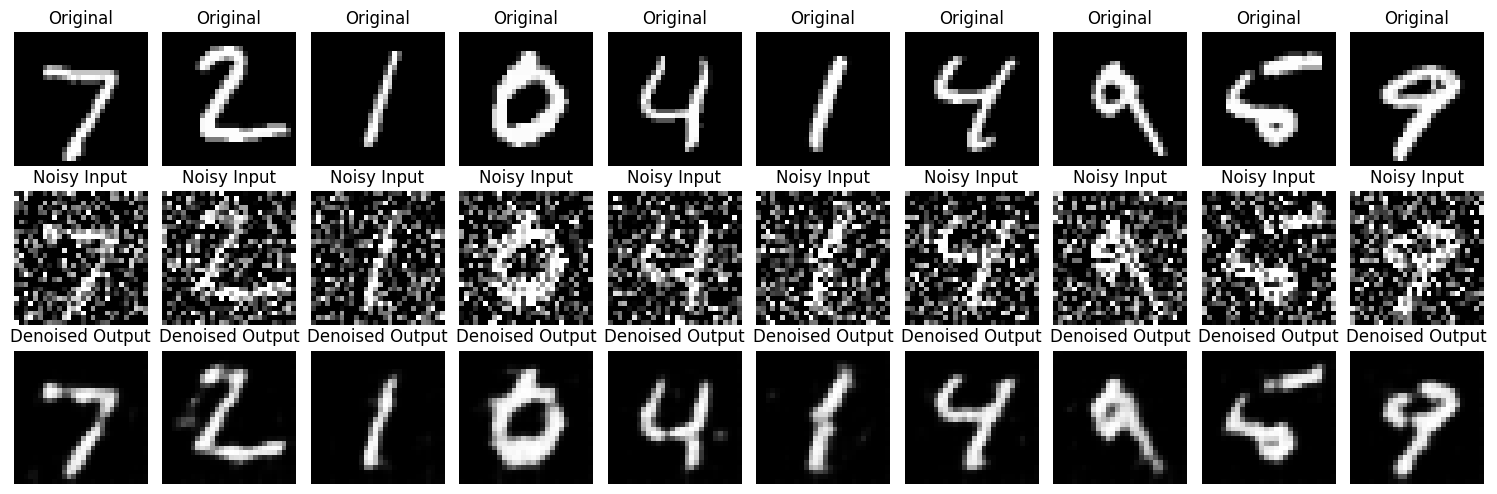

In [17]:
model.eval()
test_imgs = next(iter(test_loader))[0][:10]
noisy_test_imgs = add_noise(test_imgs).to(device)

with torch.no_grad():
    reconstructed = model(noisy_test_imgs)

# Plot
n = 10
plt.figure(figsize=(15, 5))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(test_imgs[i][0], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_test_imgs[i][0].cpu(), cmap="gray")
    plt.title("Noisy Input")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed[i][0].cpu(), cmap="gray")
    plt.title("Denoised Output")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Denoising Autoencoder for Color Images (CIFAR-10)

100%|████████████████████████████████████████| 170M/170M [00:43<00:00, 3.92MB/s]


Epoch [1/20], Loss: 0.5788
Epoch [2/20], Loss: 0.5635
Epoch [3/20], Loss: 0.5615
Epoch [4/20], Loss: 0.5604
Epoch [5/20], Loss: 0.5597
Epoch [6/20], Loss: 0.5592
Epoch [7/20], Loss: 0.5588
Epoch [8/20], Loss: 0.5583
Epoch [9/20], Loss: 0.5581
Epoch [10/20], Loss: 0.5579
Epoch [11/20], Loss: 0.5576
Epoch [12/20], Loss: 0.5574
Epoch [13/20], Loss: 0.5572
Epoch [14/20], Loss: 0.5569
Epoch [15/20], Loss: 0.5568
Epoch [16/20], Loss: 0.5566
Epoch [17/20], Loss: 0.5565
Epoch [18/20], Loss: 0.5563
Epoch [19/20], Loss: 0.5562
Epoch [20/20], Loss: 0.5561


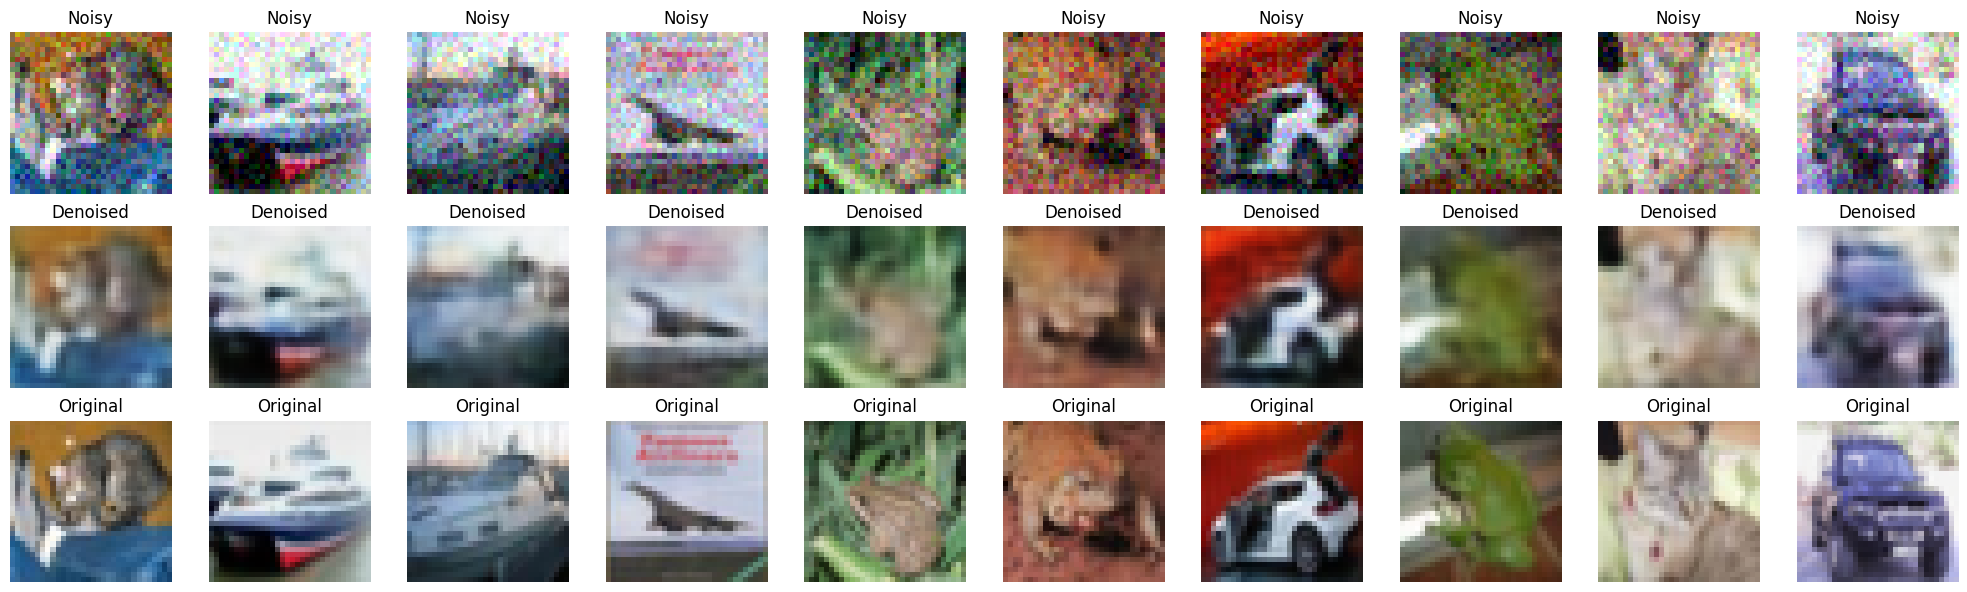

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CIFAR-10
transform = transforms.ToTensor()
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Convert to tensors
x_train = torch.stack([d[0] for d in train_data])  # shape: (50000, 3, 32, 32)
x_test = torch.stack([d[0] for d in test_data])    # shape: (10000, 3, 32, 32)

# Add Gaussian noise
noise_factor = 0.1
x_train_noisy = x_train + noise_factor * torch.randn_like(x_train)
x_test_noisy = x_test + noise_factor * torch.randn_like(x_test)
x_train_noisy = torch.clamp(x_train_noisy, 0., 1.)
x_test_noisy = torch.clamp(x_test_noisy, 0., 1.)

# Dataloaders
batch_size = 128
train_loader = DataLoader(TensorDataset(x_train_noisy, x_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test_noisy, x_test), batch_size=batch_size, shuffle=False)

# Define model
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(ConvDenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 32x32x64
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2, padding=0),        # 16x16x64
            nn.Conv2d(64, 32, kernel_size=3, padding=1), # 16x16x32
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2, padding=0)         # 8x8x32
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # 8x8x32
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'), # 16x16x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16x64
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'), # 32x32x64
            nn.Conv2d(64, 3, kernel_size=3, padding=1),  # 32x32x3
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instantiate model
model = ConvDenoisingAutoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}")

# Predict
model.eval()
with torch.no_grad():
    noisy_imgs, clean_imgs = next(iter(test_loader))
    noisy_imgs = noisy_imgs.to(device)
    outputs = model(noisy_imgs).cpu()
    noisy_imgs = noisy_imgs.cpu()
    clean_imgs = clean_imgs

# Plot
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(np.transpose(noisy_imgs[i].numpy(), (1, 2, 0)))
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(np.transpose(outputs[i].numpy(), (1, 2, 0)))
    plt.title("Denoised")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(np.transpose(clean_imgs[i].numpy(), (1, 2, 0)))
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Sparse Autoencoder

In [ ]:
# Why Sparsity?
Forces the model to specialize each neuron for a narrow set of patterns.
Helps avoid trivial identity mappings.
Leads to disentangled and interpretable features (somewhat like brain neurons firing selectively).

In [ ]:
 How Do We Enforce Sparsity?

We penalize the average activation of each hidden neuron over the training data using:
    L1 regularization, or
    KL divergence between the average activation and a target sparsity level

Epoch 1/5, Loss: 713.9496
Epoch 2/5, Loss: 53.4041
Epoch 3/5, Loss: 44.4416
Epoch 4/5, Loss: 41.6180
Epoch 5/5, Loss: 40.1009


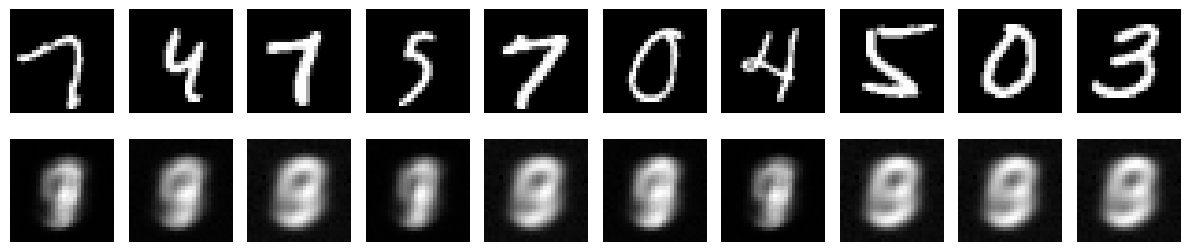

In [19]:
# Sparse with KL AE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST dataset
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# Define the Sparse Autoencoder model
class SparseAutoencoder(nn.Module):
    def __init__(self):
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Linear(28*28, 128)
        self.decoder = nn.Linear(128, 28*28)
        self.rho = 0.05  # desired average activation
        self.beta = 1    # sparsity penalty weight

    def kl_divergence(self, rho_hat):
        rho = self.rho
        return torch.sum(
            rho * torch.log(rho / (rho_hat + 1e-10)) + 
            (1 - rho) * torch.log((1 - rho) / (1 - rho_hat + 1e-10))
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = torch.sigmoid(self.encoder(x))
        x_hat = torch.sigmoid(self.decoder(z))
        return x_hat, z

# Training setup
model = SparseAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for batch in train_loader:
        imgs, _ = batch
        imgs = imgs.to(device)
        outputs, activations = model(imgs)

        # Average activation of hidden units (ρ̂)
        rho_hat = torch.mean(activations, dim=0)

        # Loss = MSE + KL Divergence
        mse_loss = criterion(outputs, imgs.view(imgs.size(0), -1))
        kl_loss = model.kl_divergence(rho_hat)
        loss = mse_loss + model.beta * kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

# Visualize original vs reconstructed images
def show_images(model, data_loader):
    model.eval()
    imgs, _ = next(iter(data_loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        recons, _ = model(imgs)

    recons = recons.view(-1, 1, 28, 28).cpu()
    imgs = imgs.cpu()

    fig, axes = plt.subplots(2, 10, figsize=(12, 3))
    for i in range(10):
        axes[0, i].imshow(imgs[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recons[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=12)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=12)
    plt.tight_layout()
    plt.show()

show_images(model, train_loader)


Epoch 1/5, Total Loss: 8.2395
Epoch 2/5, Total Loss: 2.2624
Epoch 3/5, Total Loss: 1.9770
Epoch 4/5, Total Loss: 1.8467
Epoch 5/5, Total Loss: 1.7622


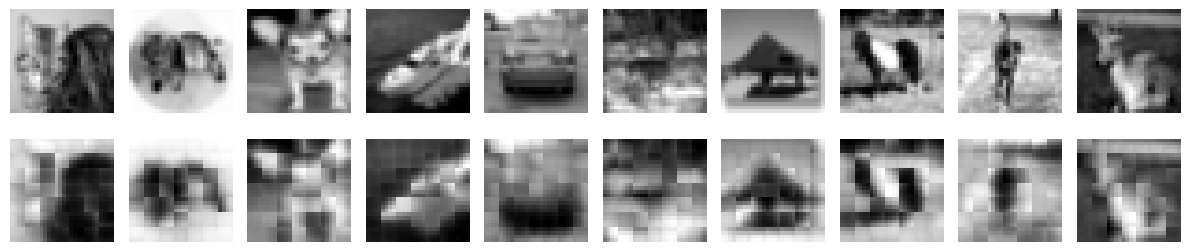

In [20]:
# Convolutional Sparse Autoencoder  on CIFAR dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load dataset (MNIST or CIFAR10 with grayscale)
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),  # for CIFAR10 to convert RGB to 1 channel
    transforms.ToTensor()
])
train_data = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# 2. CSAE Model
class ConvSparseAutoencoder(nn.Module):
    def __init__(self):
        super(ConvSparseAutoencoder, self).__init__()
        self.rho = 0.05
        self.beta = 1e-3

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # [B, 16, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # [B, 16, 14, 14]
            nn.Conv2d(16, 8, 3, padding=1),   # [B, 8, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # [B, 8, 7, 7]
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2),   # [B, 16, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),   # [B, 1, 28, 28]
            nn.Sigmoid()
        )

    def kl_divergence(self, rho_hat):
        rho = self.rho
        return torch.sum(
            rho * torch.log(rho / (rho_hat + 1e-10)) +
            (1 - rho) * torch.log((1 - rho) / (1 - rho_hat + 1e-10))
        )

    def forward(self, x):
        z = self.encoder(x)
        rho_hat = torch.mean(z, dim=(0, 2, 3))  # Avg over batch, height, width
        kl_loss = self.kl_divergence(rho_hat)
        out = self.decoder(z)
        return out, kl_loss

# 3. Training loop
model = ConvSparseAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        recon, kl_loss = model(imgs)
        mse_loss = criterion(recon, imgs)
        loss = mse_loss + model.beta * kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Total Loss: {total_loss:.4f}")

# 4. Visualize reconstructions
def show_images(model, loader):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        recons, _ = model(imgs)

    fig, axs = plt.subplots(2, 10, figsize=(12, 3))
    for i in range(10):
        axs[0, i].imshow(imgs[i].squeeze().cpu(), cmap='gray')
        axs[0, i].axis('off')
        axs[1, i].imshow(recons[i].squeeze().cpu(), cmap='gray')
        axs[1, i].axis('off')
    axs[0, 0].set_ylabel("Original")
    axs[1, 0].set_ylabel("Reconstructed")
    plt.tight_layout()
    plt.show()

show_images(model, train_loader)


Epoch [1/50], Loss: 0.649273
Epoch [2/50], Loss: 0.619976
Epoch [3/50], Loss: 0.611757
Epoch [4/50], Loss: 0.606261
Epoch [5/50], Loss: 0.602588
Epoch [6/50], Loss: 0.599485
Epoch [7/50], Loss: 0.596797
Epoch [8/50], Loss: 0.595613
Epoch [9/50], Loss: 0.594138
Epoch [10/50], Loss: 0.593884
Epoch [11/50], Loss: 0.593268
Epoch [12/50], Loss: 0.593286
Epoch [13/50], Loss: 0.593066
Epoch [14/50], Loss: 0.593098
Epoch [15/50], Loss: 0.593005
Epoch [16/50], Loss: 0.592812
Epoch [17/50], Loss: 0.592807
Epoch [18/50], Loss: 0.592691
Epoch [19/50], Loss: 0.592844
Epoch [20/50], Loss: 0.592691
Epoch [21/50], Loss: 0.592786
Epoch [22/50], Loss: 0.592721
Epoch [23/50], Loss: 0.592514
Epoch [24/50], Loss: 0.592703
Epoch [25/50], Loss: 0.592636
Epoch [26/50], Loss: 0.592434
Epoch [27/50], Loss: 0.592399
Epoch [28/50], Loss: 0.592533
Epoch [29/50], Loss: 0.592364
Epoch [30/50], Loss: 0.592301
Epoch [31/50], Loss: 0.592336
Epoch [32/50], Loss: 0.592187
Epoch [33/50], Loss: 0.592115
Epoch [34/50], Loss

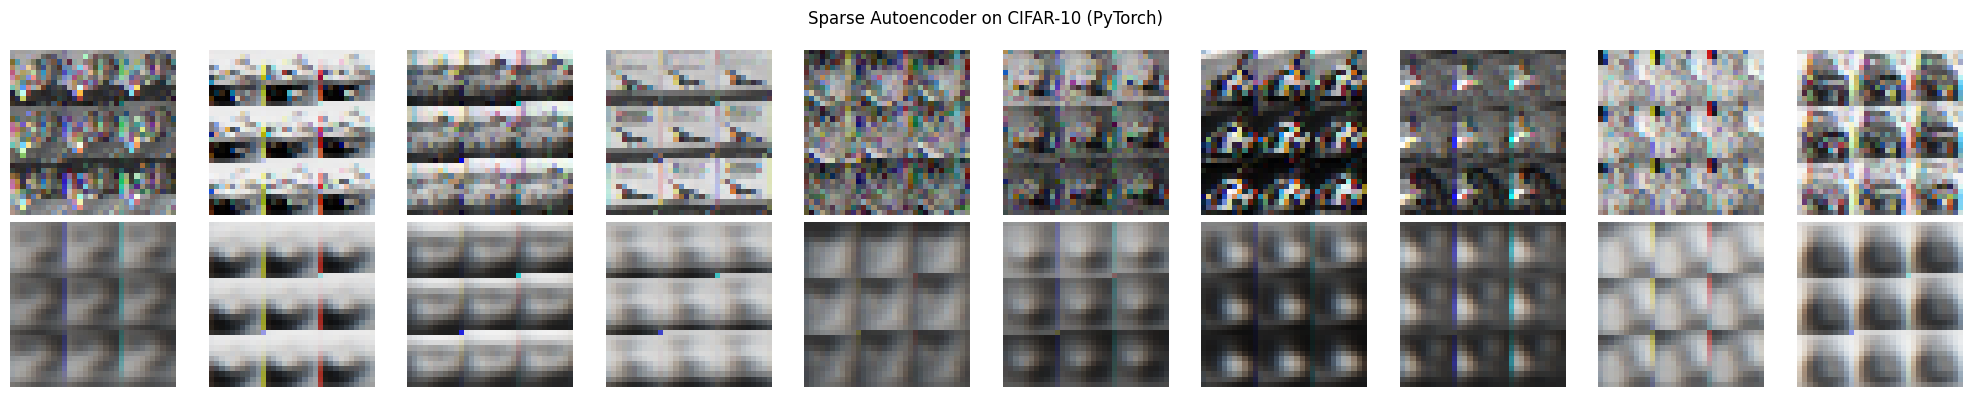

In [21]:
# Sparse Autoencoder  (with L1 Penalty on Latent Layer)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and normalize CIFAR-10
transform = transforms.ToTensor()
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Flatten and normalize
x_train = torch.stack([d[0].view(-1) for d in train_data])  # (50000, 3072)
x_test = torch.stack([d[0].view(-1) for d in test_data])    # (10000, 3072)

# DataLoader
batch_size = 256
train_loader = DataLoader(TensorDataset(x_train, x_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, x_test), batch_size=batch_size, shuffle=False)

# Sparse Autoencoder with L1 activity regularizer
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=3072, encoding_dim=256):
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, encoding_dim)
        self.decoder = nn.Linear(encoding_dim, input_dim)
        self.activation = nn.ReLU()
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        encoded = self.activation(self.encoder(x))
        decoded = self.output_activation(self.decoder(encoded))
        return decoded, encoded  # Return both for L1 penalty

model = SparseAutoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# L1 penalty coefficient (same as Keras 1e-5)
l1_lambda = 1e-5

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        outputs, encoded = model(batch_x)

        loss = criterion(outputs, batch_x)
        l1_loss = l1_lambda * torch.mean(torch.abs(encoded))  # L1 on latent activations
        total = loss + l1_loss

        optimizer.zero_grad()
        total.backward()
        optimizer.step()
        total_loss += total.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.6f}")

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_imgs = x_test[:10].to(device)
    decoded_imgs, _ = model(test_imgs)
    test_imgs = test_imgs.cpu().numpy()
    decoded_imgs = decoded_imgs.cpu().numpy()

# Plot original and reconstructed
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_imgs[i].reshape(32, 32, 3))
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(32, 32, 3))
    plt.axis("off")

plt.suptitle("Sparse Autoencoder on CIFAR-10 (PyTorch)")
plt.tight_layout()
plt.show()




Epoch [1/20], Loss: 0.011791
Epoch [2/20], Loss: 0.005667
Epoch [3/20], Loss: 0.004958
Epoch [4/20], Loss: 0.004449
Epoch [5/20], Loss: 0.004180
Epoch [6/20], Loss: 0.003961
Epoch [7/20], Loss: 0.003739
Epoch [8/20], Loss: 0.003592
Epoch [9/20], Loss: 0.003495
Epoch [10/20], Loss: 0.003350
Epoch [11/20], Loss: 0.003236
Epoch [12/20], Loss: 0.003129
Epoch [13/20], Loss: 0.003062
Epoch [14/20], Loss: 0.002927
Epoch [15/20], Loss: 0.002853
Epoch [16/20], Loss: 0.002784
Epoch [17/20], Loss: 0.002690
Epoch [18/20], Loss: 0.002659
Epoch [19/20], Loss: 0.002584
Epoch [20/20], Loss: 0.002509


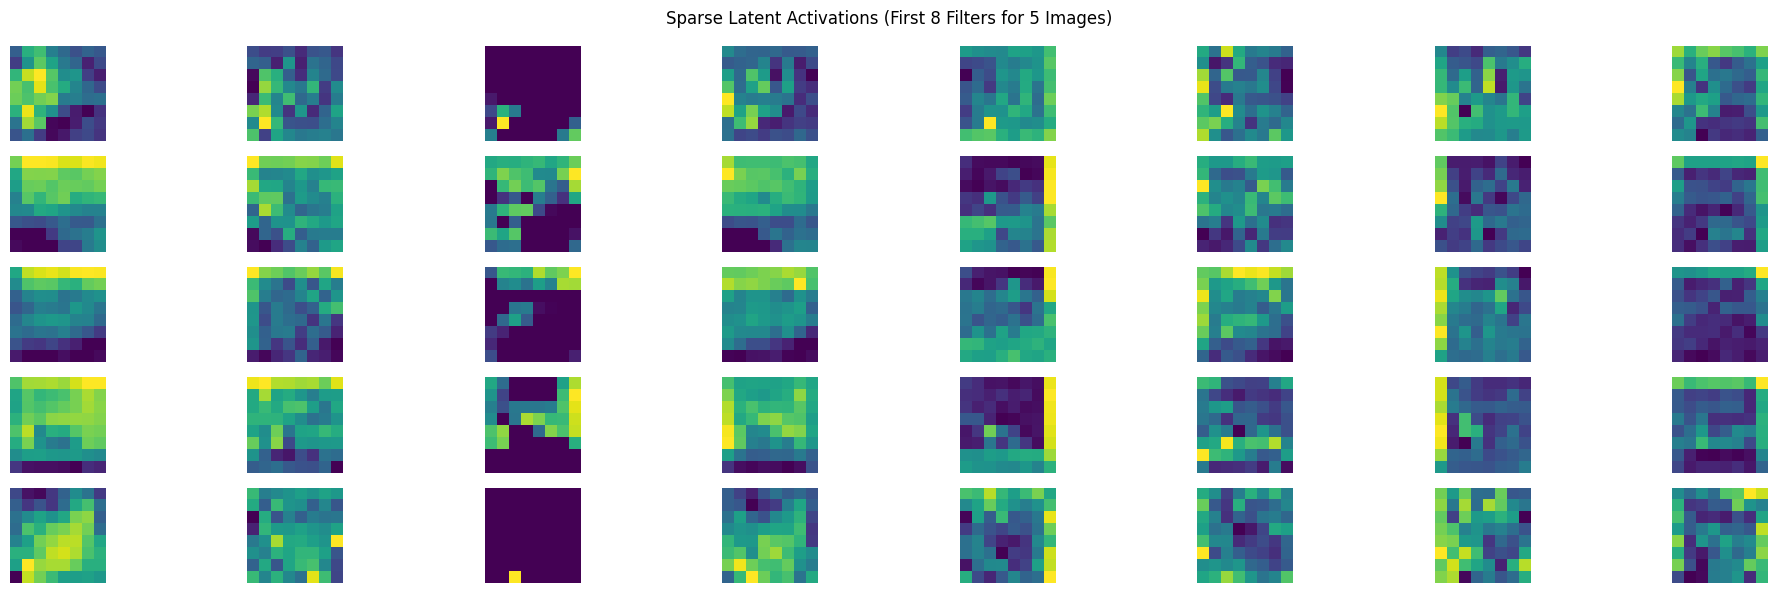

In [22]:
# Sparse Convolutional Autoencoder (Color Images with Sparsity)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CIFAR-10
transform = transforms.ToTensor()
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=10, shuffle=False)  # For visualization

# Define sparse convolutional autoencoder
class SparseConvAutoencoder(nn.Module):
    def __init__(self):
        super(SparseConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (B,32,32,32)
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2, padding=0),        # (B,32,16,16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (B,64,16,16)
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2, padding=0)         # (B,64,8,8)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # (B,64,8,8)
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'), # (B,64,16,16)
            nn.Conv2d(64, 32, kernel_size=3, padding=1), # (B,32,16,16)
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'), # (B,32,32,32)
            nn.Conv2d(32, 3, kernel_size=3, padding=1),  # (B,3,32,32)
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

model = SparseConvAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
l1_lambda = 1e-6  # L1 sparsity penalty on encoded layer

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs, encoded = model(imgs)
        
        recon_loss = criterion(outputs, imgs)
        l1_loss = l1_lambda * torch.mean(torch.abs(encoded))  # sparsity on latent
        total_loss = recon_loss + l1_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_loader):.6f}")

# Visualize Sparse Activations
model.eval()
with torch.no_grad():
    sample_imgs, _ = next(iter(test_loader))  # shape: (10, 3, 32, 32)
    sample_imgs = sample_imgs.to(device)
    _, sparse_maps = model(sample_imgs)  # shape: (10, 64, 8, 8)
    sparse_maps = sparse_maps.cpu().numpy()

# Plot sparse activations
n_images = 5      # first 5 images
n_filters = 8     # first 8 filters
plt.figure(figsize=(20, 6))

for i in range(n_images):
    for j in range(n_filters):
        ax = plt.subplot(n_images, n_filters, i * n_filters + j + 1)
        plt.imshow(sparse_maps[i, j], cmap='viridis')
        plt.axis('off')

plt.suptitle("Sparse Latent Activations (First {} Filters for {} Images)".format(n_filters, n_images))
plt.tight_layout()
plt.show()



# Variational Autoencoder

In [ ]:
# What Is a Variational Autoencoder?

A VAE differs from a regular autoencoder in that it learns to encode inputs into a probability distribution (usually Gaussian) rather than a fixed vector. 

This allows us to:
    Sample new latent vectors
    Generate new data
    Ensure smooth latent space

In [ ]:
Architecture Overview:

    Encoder:
    Learns to output mean (μ) and log-variance (logσ²) of a Gaussian for each input.

    Latent Sampling:
    Uses the reparameterization trick to allow gradient flow:
    z=μ+σ⋅ϵ,ϵ∼N(0,I)

    Decoder:
    Reconstructs input from sampled latent vector z.

    Loss Function:
    L=Reconstruction Loss+KL Divergence


In [ ]:
Unlike standard AEs, which learn a single point in latent space, VAEs learn parameters of a probability distribution 
(mean and variance) for each latent representation. This allows us to:

    Sample new data from the latent space.
    Generate new images.

Epoch 1, Loss: 221.0983
Epoch 2, Loss: 205.5532
Epoch 3, Loss: 169.0189
Epoch 4, Loss: 161.7671
Epoch 5, Loss: 159.7154
Epoch 6, Loss: 158.4858
Epoch 7, Loss: 157.6289
Epoch 8, Loss: 156.8378
Epoch 9, Loss: 156.1234
Epoch 10, Loss: 155.7070
Epoch 11, Loss: 155.2776
Epoch 12, Loss: 154.8299
Epoch 13, Loss: 154.5946
Epoch 14, Loss: 154.2276
Epoch 15, Loss: 153.9348
Epoch 16, Loss: 153.6819
Epoch 17, Loss: 153.5104
Epoch 18, Loss: 153.2906
Epoch 19, Loss: 153.0486
Epoch 20, Loss: 152.9159
Epoch 21, Loss: 152.6778
Epoch 22, Loss: 152.4638
Epoch 23, Loss: 152.3858
Epoch 24, Loss: 152.1853
Epoch 25, Loss: 152.0458
Epoch 26, Loss: 151.9205
Epoch 27, Loss: 151.8182
Epoch 28, Loss: 151.6354
Epoch 29, Loss: 151.4400
Epoch 30, Loss: 151.4066


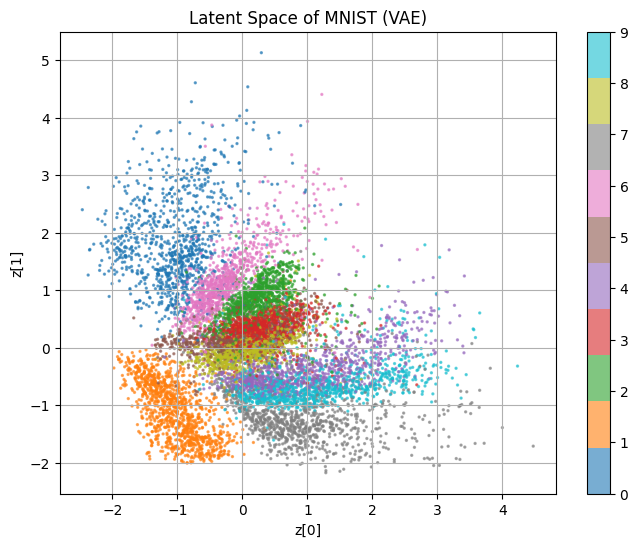

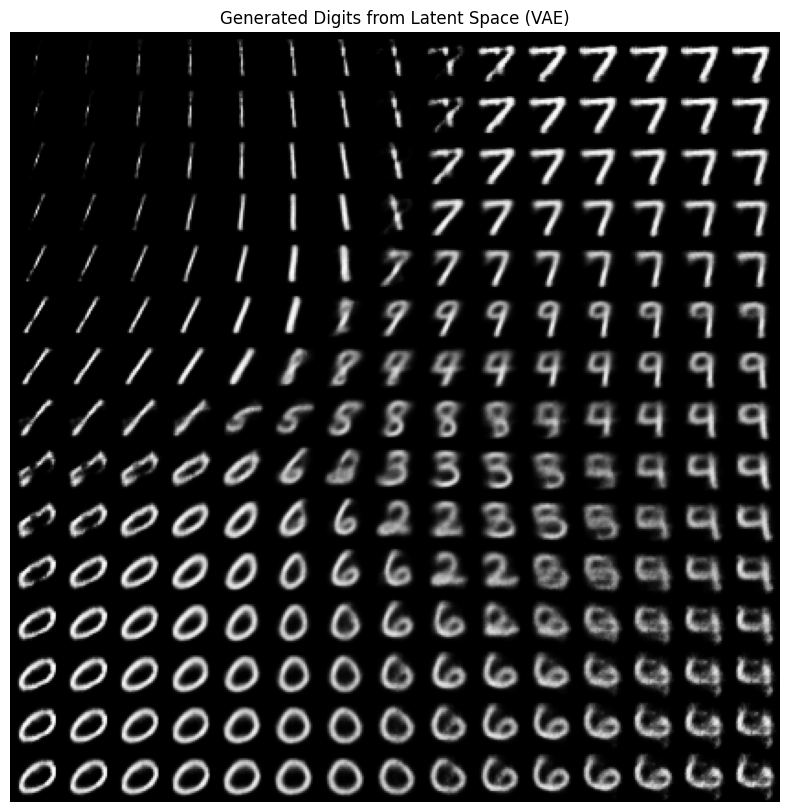

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=False)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 7x7
            nn.ReLU()
        )
        self.fc1 = nn.Linear(64 * 7 * 7, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, 3, stride=2, padding=1, output_padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 28x28
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = F.relu(self.fc2(z))
        x = x.view(-1, 64, 7, 7)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# Loss
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

# Training
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

epochs = 30
for epoch in range(epochs):
    vae.train()
    total_loss = 0
    for batch, _ in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

# Encode test set
vae.eval()
z_all = []
labels = []
with torch.no_grad():
    for batch, y in test_loader:
        batch = batch.to(device)
        mu, _ = vae.encode(batch)
        z_all.append(mu.cpu().numpy())
        labels.append(y.numpy())

z_all = np.concatenate(z_all)
labels = np.concatenate(labels)

# Plot latent space
plt.figure(figsize=(8, 6))
plt.scatter(z_all[:, 0], z_all[:, 1], c=labels, cmap='tab10', alpha=0.6, s=2)
plt.colorbar()
plt.title("Latent Space of MNIST (VAE)")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.grid(True)
plt.show()

# Generate digits from latent space
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            generated = vae.decode(z_sample).cpu().numpy().squeeze()# ---------------------------------------------- Generating
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = generated

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.title("Generated Digits from Latent Space (VAE)")
plt.axis('off')
plt.show()


In [ ]:
# CIFAR-10 + VAE (Color Images)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR-10 loader
transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(
    datasets.CIFAR10(root='./data', train=True, download=False, transform=transform),
    batch_size=128, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 128x4x4
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),    # 3x32x32
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        batch_size = x.size(0)
        x_enc = self.encoder(x)
        x_enc = x_enc.view(batch_size, -1)
        mu = self.fc_mu(x_enc)
        logvar = self.fc_logvar(x_enc)
        z = self.reparameterize(mu, logvar)
        x_dec = self.fc_decode(z).view(batch_size, 128, 4, 4)
        x_out = self.decoder(x_dec)
        return x_out, mu, logvar

# Loss: Reconstruction + KL Divergence
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

# Training
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

epochs = 10
for epoch in range(epochs):
    vae.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        recon_x, mu, logvar = vae(x)
        loss = vae_loss(recon_x, x, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader.dataset):.4f}")


Epoch [1/10], Loss: 112.2685
Epoch [2/10], Loss: 83.0068
Epoch [3/10], Loss: 79.5997
Epoch [4/10], Loss: 78.5178
Epoch [5/10], Loss: 77.7991
Epoch [6/10], Loss: 77.1297
Epoch [7/10], Loss: 76.6540
Epoch [8/10], Loss: 76.2122
Epoch [9/10], Loss: 76.0323
Epoch [10/10], Loss: 75.7124


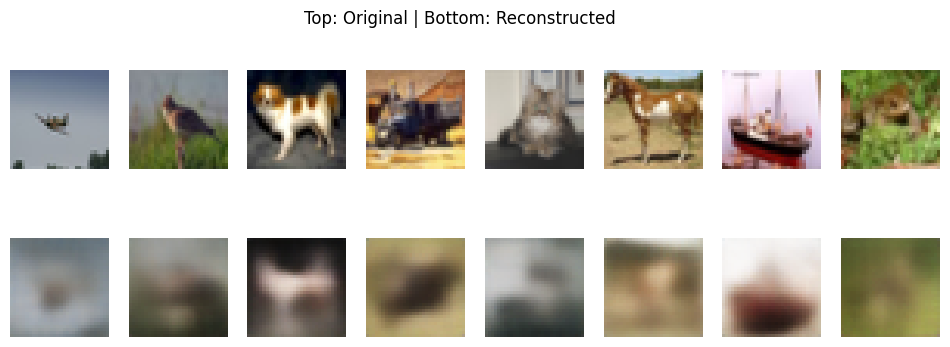

In [25]:
# Plot sample reconstructions

vae.eval()
x, _ = next(iter(train_loader))
x = x.to(device)[:8]
with torch.no_grad():
    x_recon, _, _ = vae(x)

x = x.cpu()
x_recon = x_recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(x[i].permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].permute(1, 2, 0))
    axes[1, i].axis('off')
plt.suptitle("Top: Original | Bottom: Reconstructed")
plt.show()


# Contractive Autoencoder
(Penalizes the sensitivity of the input variation)

In [ ]:
#  What is a Contractive Autoencoder?

A Contractive Autoencoder is designed to learn robust representations by adding a penalty that discourages sensitivity to small input variations. 
This is especially useful for manifold learning where we want the latent space to change slowly in response to small changes in input.

In [ ]:
In addition to the normal reconstruction loss, a Contractive AE adds a regularization term:

L=∥x−x^∥2+λ⋅∥∇h(x)∥2


Where:

    ∥x−x^∥^2 is the usual reconstruction loss.

    ∥∇h(x)∥^2 is the Frobenius norm of the Jacobian of the encoder’s output w.r.t input — it penalizes the sensitivity of the hidden representation.

    λλ is a regularization weight.

In [ ]:
Encourages robust and invariant features.
Helps model to "contract" around the manifold of real data.
Useful for representation learning and anomaly detection.

In [26]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Load MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=False)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 32)  # latent dim

    def forward(self, x):
        x = x.view(-1, 28*28)
        x1 = self.fc1(x)
        h = self.relu(x1)
        z = self.fc2(h)
        return z, h, x1  # return intermediate values for Jacobian

# Decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(32, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 28 * 28)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        x = self.relu(self.fc1(z))
        x = self.sigmoid(self.fc2(x))
        return x

# Contractive AE
class ContractiveAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z, h, x1 = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, h, x1

# Jacobian Frobenius Norm
def contractive_loss(x, x_hat, h, x1, model, lam=1e-4):
    mse = nn.functional.mse_loss(x_hat, x.view(x_hat.size()))
    # dH/dX approx = W * dReLU/dX
    dh = h * (1 - h)  # derivative of ReLU is 0 or 1; here for Sigmoid it's h*(1-h) (optional)
    W = model.encoder.fc1.weight  # shape: [128, 784]
    W_squared = W.pow(2)
    contractive = torch.sum(torch.mm(dh.pow(2), W_squared))
    return mse + lam * contractive

# Train loop
model = ContractiveAutoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for images, _ in train_loader:
        x_hat, h, x1 = model(images)
        loss = contractive_loss(images, x_hat, h, x1, model)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/5], Loss: {loss.item():.4f}")


Epoch [1/5], Loss: 0.0591
Epoch [2/5], Loss: 0.0489
Epoch [3/5], Loss: 0.0428
Epoch [4/5], Loss: 0.0364
Epoch [5/5], Loss: 0.0354


# A Contractive Autoencoder (CAE) is a type of autoencoder that includes a regularization term that penalizes the sensitivity of the encoder to small input changes.

Epoch 1, Loss: 0.0627
Epoch 2, Loss: 0.0573
Epoch 3, Loss: 0.0431
Epoch 4, Loss: 0.0377
Epoch 5, Loss: 0.0377
Epoch 6, Loss: 0.0334
Epoch 7, Loss: 0.0315
Epoch 8, Loss: 0.0313
Epoch 9, Loss: 0.0305
Epoch 10, Loss: 0.0295


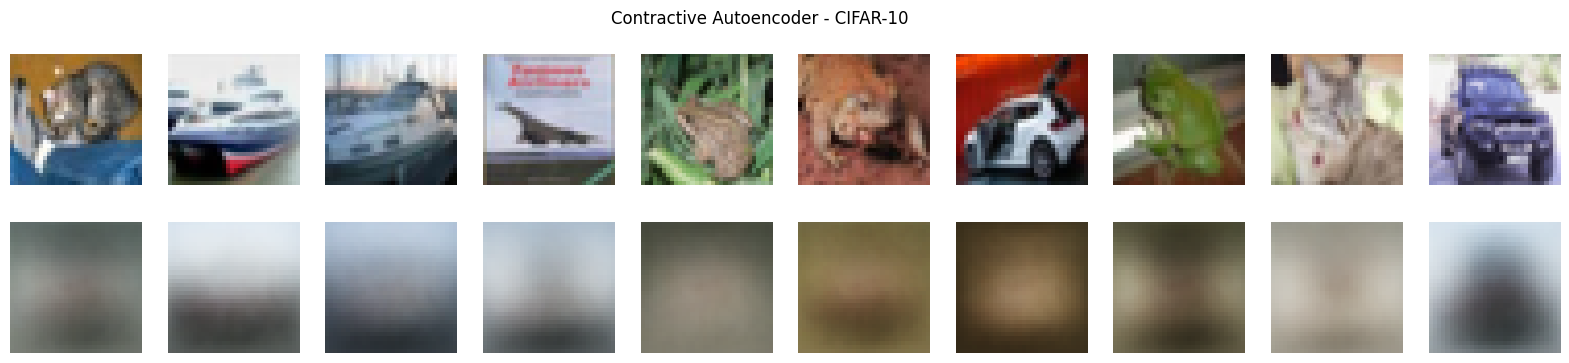

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Load CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)

# 2. Define Contractive Autoencoder
class ContractiveAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),                           # [B, 32*32*3]
            nn.Linear(32*32*3, 512),
            nn.Sigmoid(),                           # Use Sigmoid for contractive loss derivative
            nn.Linear(512, 128),
            nn.Sigmoid()
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 32*32*3),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

# Move model to GPU
model = ContractiveAutoencoder().cuda()

# 3. Contractive Loss Function
def contractive_loss(x, x_recon, z, model, lam=1e-4):
    recon_loss = nn.functional.mse_loss(x_recon, x.view(x.size(0), -1))

    # Get weights of first linear layer (encoder[1])
    W = list(model.encoder[1].parameters())[0]  # shape: [512, 3072]
    
    # Get activation before that layer (after sigmoid at encoder[2])
    h = model.encoder[2](model.encoder[1](x.view(x.size(0), -1)))  # shape: [batch, 512]
    dh = h * (1 - h)  # sigmoid derivative
    
    # Compute Frobenius norm term
    # Each row in W: weights for one neuron, sum across columns
    W_squared = W.pow(2).sum(dim=1)  # shape: [512]
    contractive_term = torch.sum(dh.pow(2) @ W_squared)  # shape: scalar

    return recon_loss + lam * contractive_term

# 4. Training
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()
    total_loss = 0
    for inputs, _ in trainloader:
        inputs = inputs.cuda()
        optimizer.zero_grad()
        x_recon, z = model(inputs)
        loss = contractive_loss(inputs, x_recon, z, model)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(trainloader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# 5. Visualize reconstruction
import numpy as np

model.eval()
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=10, shuffle=False)

# Get a batch
data_iter = iter(testloader)
images, _ = next(data_iter)
images = images.cuda()
recon, _ = model(images)

# Plot
plt.figure(figsize=(20, 4))
for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).cpu().detach().numpy())
    plt.axis('off')
    
    # Reconstructed
    ax = plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(recon[i].view(3, 32, 32).permute(1, 2, 0).cpu().detach().numpy())
    plt.axis('off')

plt.suptitle("Contractive Autoencoder - CIFAR-10")
plt.show()


In [ ]:
| Variant                | Uses FC Layers?           | Learns compressed code? | Good for images? | Generative? |
| ---------------------- | ------------------------- | ----------------------- | ---------------- | ----------- |
| Basic AE (what we did) | Yes                     |  Yes                   | Not ideal      | No        |
| ConvAE                 |  No (Conv instead)       | Yes                   | Yes            | No        |
| Denoising AE           | Both                  | Yes                   | Yes            | No        |
| Sparse AE              | Yes (with L1)           | Yes (sparse)          | Often FC       | No        |
| VAE                    | Yes + Gaussian sampling | Yes (distribution)    | Yes            | Yes       |


In [ ]:

1. Variational Autoencoder (VAE)
•	Use case: Captures complex distributions, can generate synthetic data, good for detecting anomalies that deviate from learned probability distributions.
•	How it works: Learns a latent space as a probability distribution (mean and variance), not just a fixed encoding.
•	Why interesting for logistics: Could generate “normal” operational scenarios; anything far from this distribution can be flagged as anomalous.
•	Example libraries: TensorFlow, PyTorch.
•	Visual idea: Show how VAE reconstructs normal vs. anomalous routes/shipments.
________________________________________
2. Convolutional Autoencoder (CAE)
•	Use case: Spatial patterns, image-like data, or multivariate time series (reshape sequences into 2D).
•	Why interesting for logistics: If you have sensor grids, warehouse layouts, or heatmaps of traffic/flows, CAEs can pick up spatial anomalies.
•	Example: Detect anomalies in delivery maps or warehouse storage layouts.
________________________________________
3. Denoising Autoencoder (DAE)
•	Use case: Learns to reconstruct clean input from noisy data.
•	Why interesting for logistics:
                   
o	Real-world logistics data can be noisy (missing sensor readings, delayed entries).
o	A DAE can be trained on clean historical data and flag deviations as anomalies.
•	Twist: Instead of noise, intentionally mask parts of sequences to force the network to learn robust patterns.
________________________________________
4. Sparse Autoencoder
•	Use case: Learns compressed representations with sparsity constraints.
•	Why interesting for logistics:
o	Highlights only the most relevant features for anomaly detection.
o	Can be used to detect unusual patterns in high-dimensional tabular data (like shipment logs).
